# Cluster User based filtering

In [33]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import umap

In [34]:
movies = pd.read_csv("../data/csv/movies.csv")
ratings = pd.read_csv("../data/csv/ratings.csv")

In [35]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [36]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [37]:
# little helper function to get genre ratings, important when we want to cluster users by their movie preferences. returns a DataFrame where each column corresponds
# to a genre and each row corresponds to a user, with the values being the average ratings for that genre that the user has given to movies in that genre.
def get_genre_ratings(ratings, movies, genres, column_names):
    genre_ratings = pd.DataFrame()
    for genre in genres:
        genre_movies = movies[movies['genres'].str.contains(genre)]
        genre_ratings[genre] = ratings[ratings['movieId'].isin(genre_movies['movieId'])].groupby('userId')['rating'].mean()
    genre_ratings = genre_ratings.fillna(0)
    genre_ratings.columns = column_names
    return genre_ratings

In [38]:
# get all genres from the movies DataFrame
genres = set()
for genre_list in movies['genres'].str.split('|'):
    genres.update(genre_list)
# create the column names for the genre ratings DataFrame avg_{genre}_rating for each genre
genres = sorted(genres)
genre_columns = {genre: f'avg_{genre.lower()}_rating' for genre in genres}

genre_ratings = get_genre_ratings(ratings, movies, genre_columns, genres)
genre_ratings.head()

/tmp/ipykernel_689/1366261861.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  genre_movies = movies[movies['genres'].str.contains(genre)]


,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,
3,3.500000,3.640719,3.689394,3.980000,3.708333,3.454545,3.886364,3.166667,3.890086,3.737179,4.300000,3.544444,3.734568,3.583333,3.891667,3.533333,3.696429,3.692469,3.692308,3.750000
84,3.833333,2.963415,3.100000,3.578947,3.550000,3.397059,3.562500,3.447368,3.575893,3.722222,3.642857,3.285714,3.166667,3.444444,3.532258,3.484127,3.261364,3.491228,3.346154,3.750000
181,3.250000,1.782700,1.702899,0.866667,1.090909,1.563679,1.853659,1.300000,1.941304,1.661290,2.400000,2.080128,1.269231,0.928571,2.095588,1.468254,1.962963,1.934211,1.843750,2.045455
187,5.000000,3.935961,3.892361,3.742991,3.529851,3.703767,4.025907,4.220588,4.075221,3.737113,3.750000,3.746964,3.950000,3.785714,3.963710,3.734483,3.977528,3.963190,4.140625,3.681818
208,5.000000,4.096154,4.065217,3.700000,3.700000,4.319444,4.455882,0.000000,4.321429,3.892857,0.000000,4.500000,3.740000,4.000000,4.666667,4.285714,4.325000,4.260417,4.000000,3.500000


/var/data/python/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/data/python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


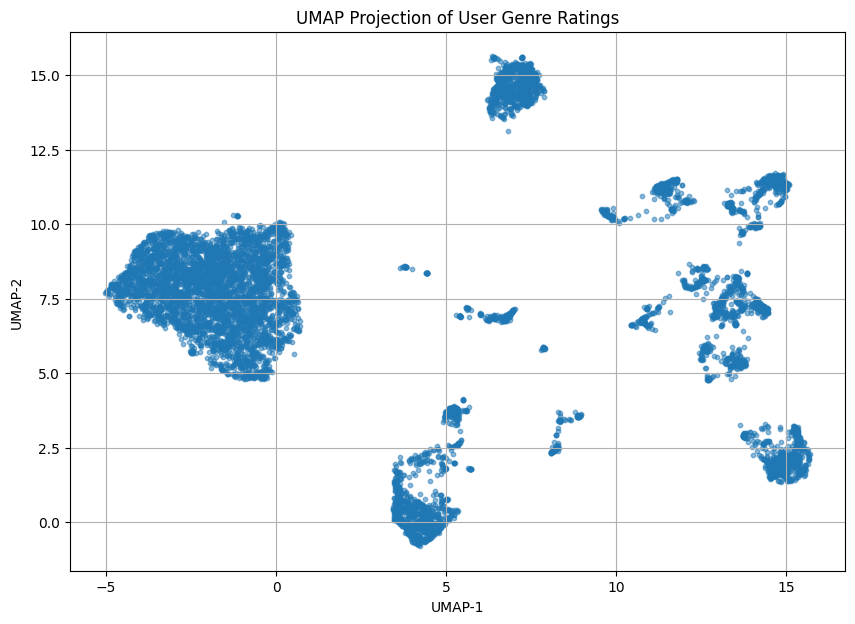

In [39]:
reducer = umap.UMAP(metric="cosine", random_state=42)
embedding = reducer.fit_transform(genre_ratings)

plt.figure(figsize=(10, 7))
plt.scatter(embedding[:, 0], embedding[:, 1], alpha=0.5, s=10)
plt.title("UMAP Projection of User Genre Ratings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.show()

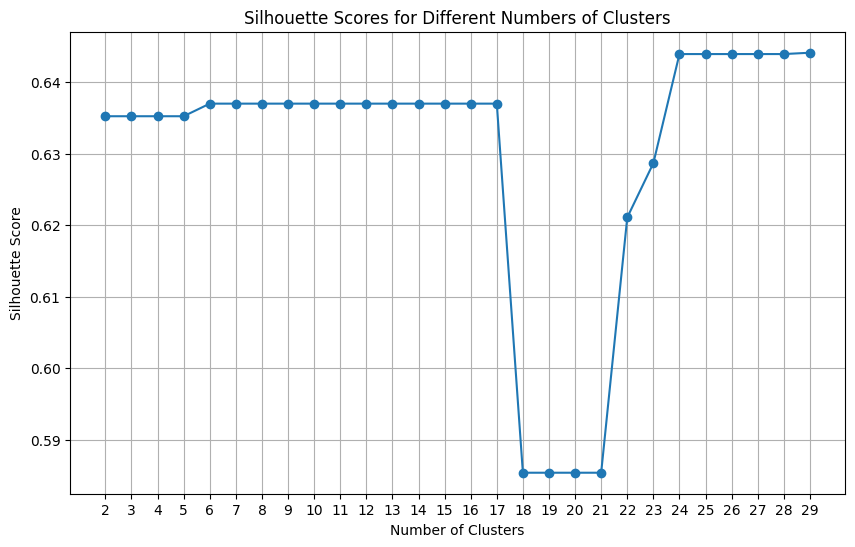

In [40]:
# plot silhouette scores for different numbers of clusters on the UMAP embedding of the genre ratings (DBSCAN)
silhouette_scores = []
for n_clusters in range(2, 30):
    dbscan = DBSCAN(eps=0.5, min_samples=n_clusters)
    labels = dbscan.fit_predict(embedding)
    if len(set(labels)) > 1:  # at least two clusters are needed for silhouette score
        score = silhouette_score(embedding, labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(-1)  # invalid score for single cluster
plt.figure(figsize=(10, 6))
plt.plot(range(2, 30), silhouette_scores, marker='o')
plt.title("Silhouette Scores for Different Numbers of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 30))
plt.grid(True)

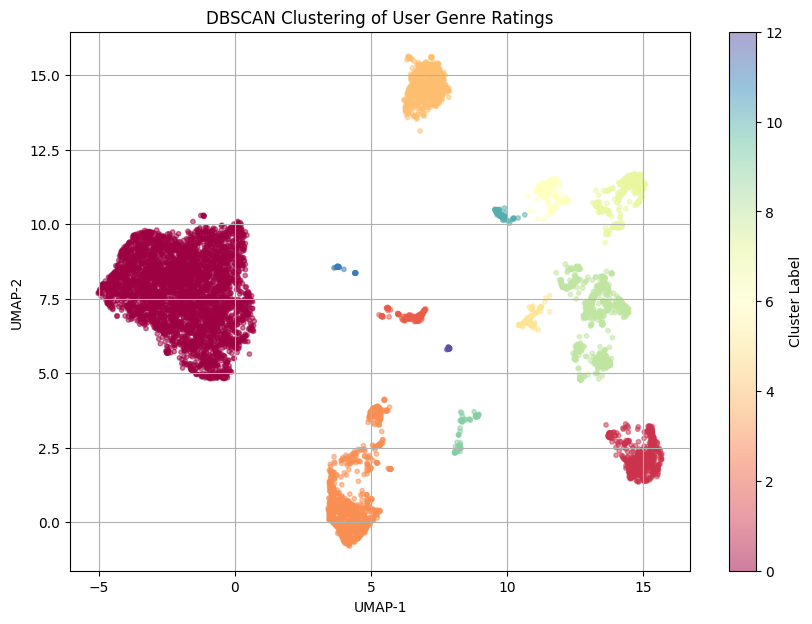

In [41]:
# apply DBSCAN clustering on the UMAP embedding of the genre ratings
dbscan = DBSCAN(eps=0.5, min_samples=7)
labels = dbscan.fit_predict(embedding)

# Add cluster labels to the genre ratings DataFrame
genre_ratings['cluster'] = labels

# plot the clusters on the UMAP embedding
plt.figure(figsize=(10, 7))
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral', alpha=0.5, s=10)
plt.title("DBSCAN Clustering of User Genre Ratings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

# Subclustering
Idea: After Clustering the users by genre we can cluster them once more based on which movies they have watched and what rating they gave it
This should ensure that only users/interactions are considered who are similar in genre and in movies they have watched

In [42]:
from scipy.sparse import coo_matrix
from sklearn.preprocessing import normalize
import numpy as np
import umap
from sklearn.cluster import DBSCAN
import hdbscan

# Step 1: Build sparse user × movie rating matrix
user_id_map = ratings['userId'].astype('category')
movie_id_map = ratings['movieId'].astype('category')

user_index = user_id_map.cat.codes
movie_index = movie_id_map.cat.codes
rating_values = ratings['rating'].astype(float)

sparse_matrix = coo_matrix((rating_values, (user_index, movie_index))).tocsr()
sparse_matrix = normalize(sparse_matrix, norm='l2')

In [43]:
# Step 2: Map genre_ratings['user_id'] to same user_index
genre_ratings = genre_ratings.copy()
genre_ratings['user_index'] = genre_ratings.index.map(
    dict(zip(user_id_map, user_index))
)

In [44]:
# Step 3: Cluster per genre group using the ratings matrix
all_embeddings = []
all_labels = []

for cluster_id in genre_ratings['cluster'].unique():
    cluster_users = genre_ratings[genre_ratings['cluster'] == cluster_id]
    user_indices = cluster_users['user_index'].dropna().astype(int).values

    if len(user_indices) < 10:
        continue  # skip very small clusters

    X = sparse_matrix[user_indices]

    # Dimensionality reduction
    reducer = umap.UMAP(metric="cosine", random_state=42)
    sub_embedding = reducer.fit_transform(X)

    # Replace DBSCAN with HDBSCAN
    clusterer = hdbscan.HDBSCAN(min_cluster_size=10, metric='euclidean')  # or 'manhattan', 'cosine' if needed
    labels = clusterer.fit_predict(sub_embedding)

    # Save labels
    genre_ratings.loc[cluster_users.index, 'sub_cluster'] = labels
    all_embeddings.append(sub_embedding)
    all_labels.append(labels)

/var/data/python/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/data/python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/data/python/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/data/python/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/data/python/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/data/python/lib/python3.11/site-packages/sklearn

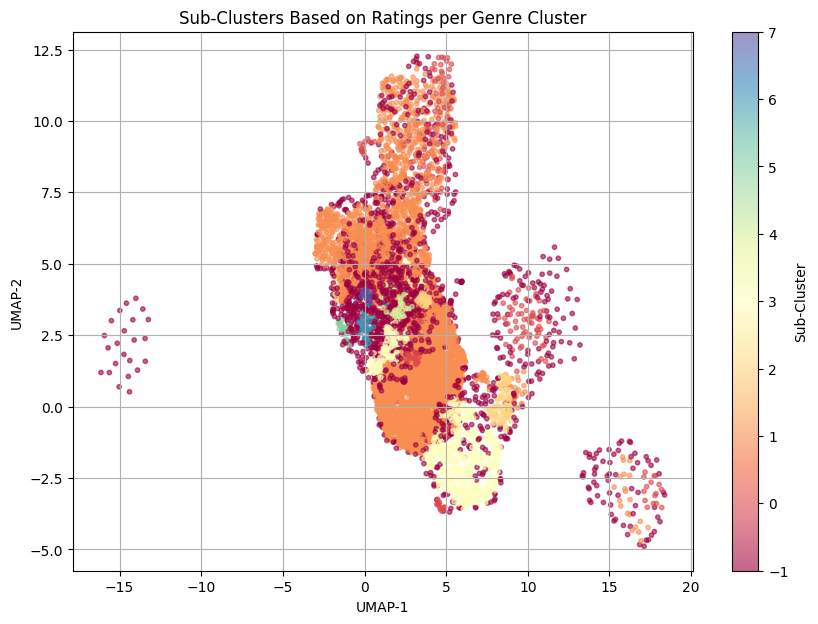

In [45]:
import matplotlib.pyplot as plt

all_embeddings = np.vstack(all_embeddings)
all_labels = np.hstack(all_labels)

plt.figure(figsize=(10, 7))
plt.scatter(all_embeddings[:, 0], all_embeddings[:, 1], c=all_labels, cmap='Spectral', alpha=0.6, s=10)
plt.title("Sub-Clusters Based on Ratings per Genre Cluster")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label='Sub-Cluster')
plt.grid(True)
plt.show()


In [46]:
sorted(genre_ratings['sub_cluster'].dropna().unique())

[-1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def userwise_train_test_split(ratings_df, test_size=0.2, user_fraction=0.2, random_state=42):
    # Get unique users and sample a fraction
    unique_users = ratings_df['userId'].unique()
    selected_users = np.random.RandomState(seed=random_state).choice(
        unique_users, size=int(len(unique_users) * user_fraction), replace=False
    )

    # Filter ratings to only include selected users
    filtered_df = ratings_df[ratings_df['userId'].isin(unique_users)]

    train_rows = []
    test_rows = []

    for user_id, group in filtered_df.groupby('userId'):
        if len(group) < 5:
            train_rows.append(group)
            continue

        train, test = train_test_split(
            group,
            test_size=test_size,
            random_state=random_state
        )
        train_rows.append(train)
        test_rows.append(test)

    train_df = pd.concat(train_rows).reset_index(drop=True)
    test_df = pd.concat(test_rows).reset_index(drop=True)

    return train_df, test_df


In [59]:
train_ratings, test_ratings = userwise_train_test_split(ratings, test_size=0.2)

print(f"Train size: {len(train_ratings)}")
print(f"Test size: {len(test_ratings)}")

print(f"Unique users in train: {train_ratings['userId'].nunique()}")
print(f"Unique users in test: {test_ratings['userId'].nunique()}")
print(f"Unique users in rating: {ratings['userId'].nunique()}")

Train size: 19936012
Test size: 5064083
Unique users in train: 162541
Unique users in test: 162541
Unique users in rating: 162541


# User KNN

In [15]:
from sklearn.neighbors import NearestNeighbors

# Store per-cluster NearestNeighbors models and user indices
cluster_knn_models = {}
cluster_user_indices = {}

for cluster_id in genre_ratings['cluster'].unique():
    user_indices = genre_ratings[genre_ratings['cluster'] == cluster_id]['user_index'].dropna().astype(int).values
    if len(user_indices) < 10:
        continue

    cluster_matrix = sparse_matrix[user_indices]
    knn = NearestNeighbors(n_neighbors=25, metric='cosine')
    knn.fit(cluster_matrix)

    cluster_knn_models[cluster_id] = knn
    cluster_user_indices[cluster_id] = user_indices


In [16]:
def recommend_from_rated_movies(input_ratings_dict, movie_id_map, cluster_knn_models, cluster_user_indices):
    """
    input_ratings_dict: {movieId: rating}
    movie_id_map: pd.Series like `ratings['movieId'].astype('category')`
    Returns: DataFrame of unique recommended movieIds sorted by rating
    """

    from scipy.sparse import csr_matrix
    import numpy as np

    # Step 1: Build sparse input vector (1 × num_movies)
    num_movies = len(movie_id_map.cat.categories)
    input_vector = np.zeros((1, num_movies))

    for mid, rating in input_ratings_dict.items():
        if mid in movie_id_map.cat.categories:
            idx = movie_id_map.cat.categories.get_loc(mid)
            input_vector[0, idx] = rating

    input_vector_sparse = csr_matrix(input_vector)

    # Step 2: Find best-matching cluster via nearest neighbor distance
    best_cluster = None
    best_score = float('inf')

    for cluster_id, knn_model in cluster_knn_models.items():
        dist, _ = knn_model.kneighbors(input_vector_sparse, n_neighbors=1)
        if dist[0][0] < best_score:
            best_score = dist[0][0]
            best_cluster = cluster_id

    if best_cluster is None:
        return []

    # Step 3: Get top 25 users from that cluster
    knn = cluster_knn_models[best_cluster]
    n_neighbors = min(25, knn.n_samples_fit_)
    distances, indices = knn.kneighbors(input_vector_sparse, n_neighbors=n_neighbors)
    user_rows = cluster_user_indices[best_cluster][indices[0]]

    # Step 4: Retrieve and sort ratings from those users
    matched_user_ids = movie_id_map.index.to_series().iloc[user_rows].values
    user_ratings = ratings[ratings['userId'].isin(matched_user_ids)].copy()

    # Remove movies already rated by the input user
    user_ratings = user_ratings[~user_ratings['movieId'].isin(input_ratings_dict.keys())]

    # Sort by rating and drop duplicates (keep highest-rated version of each movie)
    user_ratings = user_ratings.sort_values(by='rating', ascending=False)
    unique_recommendations = user_ratings.drop_duplicates(subset='movieId')

    return unique_recommendations[['movieId', 'rating']].reset_index(drop=True)


In [17]:
input_ratings = {1: 5.0, 47: 4.0, 150: 4.5}  # new user rated these movies

recommendations = recommend_from_rated_movies(
    input_ratings,
    movie_id_map=ratings['movieId'].astype('category'),
    cluster_knn_models=cluster_knn_models,
    cluster_user_indices=cluster_user_indices
)

print(recommendations.head(10))


   movieId  rating
0     4466     5.0
1     4571     5.0
2     4776     5.0
3      553     5.0
4     4355     5.0
5      832     5.0
6     4262     5.0
7     4226     5.0
8     4148     5.0
9     1073     5.0


## Test User KNN

In [20]:
from tqdm import tqdm
import numpy as np
from collections import defaultdict

def evaluate_recommendation_model(train_df, test_df, movie_id_map, cluster_knn_models, cluster_user_indices, k=25):
    """
    Evaluates the model using Recall@k, Precision@k, F1@k, Hit Rate@k, RMSE, NDCG@k, and Coverage.
    """
    user_movie_ratings = test_df.set_index(['userId', 'movieId'])['rating'].to_dict()
    user_test_items = test_df.groupby('userId')['movieId'].apply(set).to_dict()
    user_train_items = train_df.groupby('userId')[['movieId', 'rating']].apply(
        lambda x: dict(zip(x['movieId'], x['rating']))
    ).to_dict()

    hits = 0
    total = 0
    precision_sum = 0
    f1_sum = 0
    ndcg_sum = 0
    rmse_list = []
    coverage_set = set()
    hit_users = 0
    per_user_scores = {}

    for user_id in tqdm(user_train_items.keys(), desc="Evaluating users"):
        input_ratings = user_train_items[user_id]
        if user_id not in user_test_items or len(user_test_items[user_id]) == 0:
            continue

        recommendations = recommend_from_rated_movies(
            input_ratings,
            movie_id_map,
            cluster_knn_models,
            cluster_user_indices
        )

        recommended_ids = recommendations['movieId'].head(k).tolist()
        coverage_set.update(recommended_ids)

        relevant = user_test_items[user_id]
        hit_items = [m for m in recommended_ids if m in relevant]

        hit_count = len(hit_items)
        hits += hit_count
        total += len(relevant)

        if hit_count > 0:
            hit_users += 1

        recall = hit_count / len(relevant)
        precision = hit_count / k if k > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        per_user_scores[user_id] = {
            "recall": recall,
            "precision": precision,
            "f1": f1
        }

        precision_sum += precision
        f1_sum += f1

        # RMSE and NDCG only for hits
        for mid in hit_items:
            actual_rating = user_movie_ratings.get((user_id, mid))
            predicted_rating = recommendations[recommendations['movieId'] == mid]['rating'].values
            if actual_rating is not None and len(predicted_rating) > 0:
                rmse_list.append((predicted_rating[0] - actual_rating) ** 2)

        # NDCG
        dcg = 0
        for i, mid in enumerate(recommended_ids):
            if mid in relevant:
                dcg += 1 / np.log2(i + 2)  # rank i starts from 0
        ideal_dcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
        ndcg = dcg / ideal_dcg if ideal_dcg > 0 else 0
        ndcg_sum += ndcg

    num_users = len(per_user_scores)
    recall_at_k = hits / total if total > 0 else 0
    precision_at_k = precision_sum / num_users if num_users > 0 else 0
    f1_at_k = f1_sum / num_users if num_users > 0 else 0
    hit_rate_at_k = hit_users / num_users if num_users > 0 else 0
    rmse = np.sqrt(np.mean(rmse_list)) if rmse_list else None
    ndcg_at_k = ndcg_sum / num_users if num_users > 0 else 0
    coverage = len(coverage_set) / len(movie_id_map.cat.categories) if len(movie_id_map.cat.categories) > 0 else 0

    return {
        "recall@k": recall_at_k,
        "precision@k": precision_at_k,
        "f1@k": f1_at_k,
        "hit_rate@k": hit_rate_at_k,
        "rmse": rmse,
        "ndcg@k": ndcg_at_k,
        "coverage": coverage
    }, per_user_scores

In [21]:
metrics, per_user_scores = evaluate_recommendation_model(
    train_ratings, test_ratings,
    movie_id_map=ratings['movieId'].astype('category'),
    cluster_knn_models=cluster_knn_models,
    cluster_user_indices=cluster_user_indices,
    k=25
)
print(metrics)

Evaluating users: 100%|██████████| 32508/32508 [1:52:39<00:00,  4.81it/s]     

{'recall@k': 0.02962196010046716, 'precision@k': 0.03678725236864401, 'f1@k': 0.029002124664780606, 'hit_rate@k': 0.45598006644518274, 'rmse': 1.4313749792433148, 'ndcg@k': 0.04703132185470359, 'coverage': 0.12383355631954206}


# Item KNN

In [15]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix

cluster_item_knn_models = {}
cluster_item_indices = {}

for cluster_id in genre_ratings['cluster'].unique():
    user_indices = genre_ratings[genre_ratings['cluster'] == cluster_id]['user_index'].dropna().astype(int).values
    if len(user_indices) < 10:
        continue

    cluster_matrix = sparse_matrix[user_indices]  # shape: users × items
    item_matrix = cluster_matrix.T  # transpose: items × users

    knn = NearestNeighbors(n_neighbors=25, metric='cosine')
    knn.fit(item_matrix)

    cluster_item_knn_models[cluster_id] = knn
    cluster_item_indices[cluster_id] = np.arange(item_matrix.shape[0])  # just indices of items


In [26]:
def recommend_items_itemknn(input_ratings_dict, movie_id_map, cluster_item_knn_models, cluster_item_indices):
    from scipy.sparse import csr_matrix
    import numpy as np
    import pandas as pd

    num_movies = len(movie_id_map.cat.categories)
    input_vector = np.zeros((1, num_movies))

    for mid, rating in input_ratings_dict.items():
        if mid in movie_id_map.cat.categories:
            idx = movie_id_map.cat.categories.get_loc(mid)
            input_vector[0, idx] = rating

    input_vector_sparse = csr_matrix(input_vector)

    # Find the best-matching cluster
    best_cluster = None
    best_score = float('inf')
    for cluster_id, knn_model in cluster_item_knn_models.items():
        try:
            dist, _ = knn_model.kneighbors(input_vector_sparse, n_neighbors=1)
            if dist[0][0] < best_score:
                best_score = dist[0][0]
                best_cluster = cluster_id
        except ValueError:
            continue  # In case input shape is off for a cluster

    if best_cluster is None:
        return pd.DataFrame(columns=['movieId', 'rating'])

    # Step 2: Get similar items from that cluster
    knn = cluster_item_knn_models[best_cluster]
    cluster_indices = cluster_item_indices[best_cluster]

    # For each rated item, find similar items
    recommended_items = []
    for mid, rating in input_ratings_dict.items():
        if mid not in movie_id_map.cat.categories:
            continue

        idx = movie_id_map.cat.categories.get_loc(mid)
        input_vec = np.zeros((1, num_movies))
        input_vec[0, idx] = 1.0
        input_vec_sparse = csr_matrix(input_vec)

        distances, neighbor_indices = knn.kneighbors(input_vec_sparse, n_neighbors=10)
        for dist, nidx in zip(distances[0], neighbor_indices[0]):
            neighbor_movie_id = movie_id_map.cat.categories[cluster_indices[nidx]]
            if neighbor_movie_id not in input_ratings_dict:  # Don't recommend already-rated
                recommended_items.append((neighbor_movie_id, rating * (1 - dist)))

    if not recommended_items:
        return pd.DataFrame(columns=['movieId', 'rating'])

    # Aggregate and deduplicate by max score
    df = pd.DataFrame(recommended_items, columns=["movieId", "score"])
    df = df.groupby("movieId", as_index=False).agg({"score": "max"})
    df = df.sort_values("score", ascending=False)

    return df.rename(columns={"score": "rating"}).reset_index(drop=True)

In [27]:
input_ratings = {1: 5.0, 47: 4.0, 150: 4.5}  # new user rated these movies

recommendations = recommend_items_itemknn(
    input_ratings,
    movie_id_map=ratings['movieId'].astype('category'),
    cluster_item_knn_models=cluster_item_knn_models,
    cluster_item_indices=cluster_item_indices
)

print(recommendations.head(10))


Empty DataFrame
Columns: [movieId, rating]
Index: []


# Neural Collaborative Filtering

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Dataset class for NCF
class RatingDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_index'].values, dtype=torch.long)
        self.items = torch.tensor(df['movie_index'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

# Simple NCF model
class NCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, user_ids, item_ids):
        user_emb = self.user_embedding(user_ids)
        item_emb = self.item_embedding(item_ids)
        x = torch.cat([user_emb, item_emb], dim=-1)
        x = self.fc_layers(x)
        return x.squeeze()

# Training function
def train_ncf_model(train_df, num_users, num_items, epochs=5, batch_size=1024, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    dataset = RatingDataset(train_df)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = NCF(num_users, num_items).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        for users, items, ratings in progress_bar:
            users, items, ratings = users.to(device), items.to(device), ratings.to(device)
            optimizer.zero_grad()
            predictions = model(users, items)
            loss = loss_fn(predictions, ratings)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} - Average Loss: {avg_loss:.4f}")

    return model


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Fit encoders
user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

# Encode user and movie IDs as index
train_ratings['user_index'] = user_encoder.fit_transform(train_ratings['userId'])
train_ratings['movie_index'] = movie_encoder.fit_transform(train_ratings['movieId'])

In [70]:
train_ratings

,userId,movieId,rating,timestamp,user_index,movie_index
0,1,8786,4.0,1147877853,0,8072
1,1,5147,4.0,1147877654,0,5041
2,1,8360,4.0,1147868682,0,7734
3,1,5912,3.0,1147878698,0,5800
4,1,8327,5.0,1147879375,0,7720
...,...,...,...,...,...,...
19936007,162541,2947,1.5,1240946764,162540,2855
19936008,162541,318,4.0,1240952695,162540,314
19936009,162541,2396,4.0,1240952712,162540,2305
19936010,162541,56176,2.0,1240950697,162540,11963


In [ ]:
# If you have a test set, do the same for it:
test_ratings['user_index'] = user_encoder.transform(test_ratings['userId'])
test_ratings['movie_index'] = movie_encoder.transform(test_ratings['movieId'])


In [65]:
num_users = train_ratings['user_index'].nunique()
num_items = train_ratings['movie_index'].nunique()

ncf_model = train_ncf_model(train_ratings, num_users, num_items)


Epoch 1/5: 100%|██████████| 19469/19469 [08:22<00:00, 38.71it/s, loss=0.787]


Epoch 1/5 - Average Loss: 0.8565


Epoch 2/5: 100%|██████████| 19469/19469 [08:21<00:00, 38.83it/s, loss=0.76] 


Epoch 2/5 - Average Loss: 0.7443


Epoch 3/5: 100%|██████████| 19469/19469 [08:21<00:00, 38.80it/s, loss=0.76] 


Epoch 3/5 - Average Loss: 0.7315


Epoch 4/5: 100%|██████████| 19469/19469 [08:21<00:00, 38.82it/s, loss=0.802]


Epoch 4/5 - Average Loss: 0.7166


Epoch 5/5: 100%|██████████| 19469/19469 [08:15<00:00, 39.29it/s, loss=0.689]

Epoch 5/5 - Average Loss: 0.7021


In [67]:
def recommend_for_new_user(input_ratings, model, movie_id_map, index_to_movie_id, top_k=10):
    """
    input_ratings: dict {movieId: rating}
    model: trained NCF model
    movie_id_map: pd.Series with categorical dtype for movieId
    index_to_movie_id: list of all movie IDs by index
    top_k: number of recommendations
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    # Encode input into user embedding (average of rated items)
    known_movie_indices = []
    known_ratings = []
    for mid, rating in input_ratings.items():
        try:
            idx = movie_id_map.get(mid)
            if idx is not None:
                known_movie_indices.append(idx)
                known_ratings.append(rating)
        except KeyError:
            continue  # skip unknown movieId

    if not known_movie_indices:
        raise ValueError("No known movie IDs from input found in movie_id_map.")

    known_movie_tensor = torch.tensor(known_movie_indices, dtype=torch.long).to(device)
    known_ratings_tensor = torch.tensor(known_ratings, dtype=torch.float32).to(device)

    # Create fake user embedding as weighted average of rated item embeddings
    with torch.no_grad():
        item_embs = model.item_embedding(known_movie_tensor)
        weights = known_ratings_tensor.view(-1, 1)
        user_embedding = (item_embs * weights).sum(dim=0) / weights.sum()

    # Predict scores for all items
    all_indices = torch.arange(len(index_to_movie_id)).to(device)
    all_item_embs = model.item_embedding(all_indices)
    user_emb_expanded = user_embedding.unsqueeze(0).repeat(all_item_embs.shape[0], 1)
    x = torch.cat([user_emb_expanded, all_item_embs], dim=-1)
    predictions = model.fc_layers(x).squeeze()

    # Exclude already rated movies
    known_set = set(known_movie_indices)
    mask = torch.tensor([i not in known_set for i in range(len(index_to_movie_id))], dtype=torch.bool).to(device)
    predictions = predictions[mask]
    remaining_movie_ids = [mid for i, mid in enumerate(index_to_movie_id) if i not in known_set]

    # Get top-k recommendations
    top_indices = torch.topk(predictions, top_k).indices.cpu().numpy()
    recommended_movie_ids = [remaining_movie_ids[i] for i in top_indices]

    return recommended_movie_ids


In [72]:
# Step 1: Create proper categorical mapping
ratings['movie_index'] = ratings['movieId'].astype('category').cat.codes
movie_id_map = ratings.set_index('movieId')['movie_index']  # movieId -> index
index_to_movie_id = ratings['movieId'].astype('category').cat.categories.tolist()  # index -> movieId


In [73]:
input_ratings = {
    8786: 5.0,
    4703: 4.0,
    7327: 4.5
}

recommendations = recommend_for_new_user(
    input_ratings=input_ratings,
    model=ncf_model,
    movie_id_map=ratings['movieId'].astype('category'),
    index_to_movie_id=list(ratings['movieId'].astype('category').cat.categories),
    top_k=10
)

print("Top recommendations:", recommendations)

IndexError: index out of range in self